In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment is working!")

Environment is working!


In [13]:
# Core data handling and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing utilities
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# The two required, distinct supervised learning algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics -- we care about macro-averaged metrics here, not just accuracy,
# because the dataset is imbalanced (see Section 3.1)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, ConfusionMatrixDisplay)

# SMOTE: generates synthetic minority-class samples to counter class imbalance (Section 6)
from imblearn.over_sampling import SMOTE

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Fixed seed everywhere for reproducibility of splits / model training / SMOTE sampling
RANDOM_STATE = 42


In [2]:
#Load data set
 
import pandas as pd

df = pd.read_csv("../data/student_dropout_data.csv")

df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
df.shape

(4424, 37)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

# 1. Exploratory Data Analysis (EDA)

## 1.1 Dataset Overview

In [5]:
# missing values 
print("Missing values:", df.isnull().sum().sum())

# Raw counts of each outcome class
df["Target"].value_counts()

Missing values: 0


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

The central issue: class imbalance

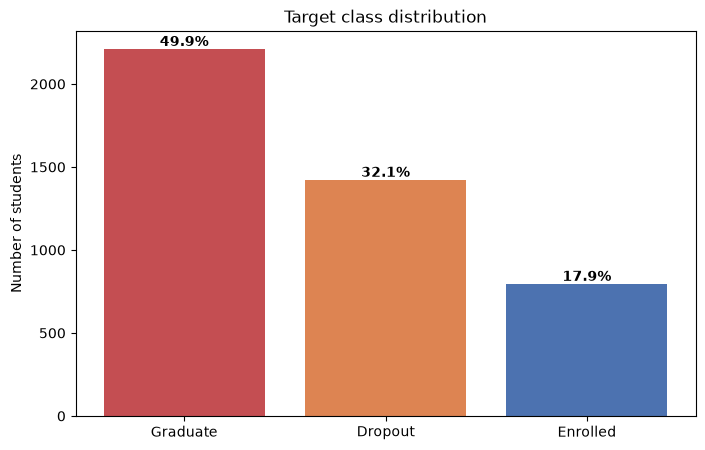

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Target
Graduate    49.9%
Dropout     32.1%
Enrolled    17.9%
Name: proportion, dtype: str


In [6]:
# Compute both raw counts and percentages of each class, since percentages make the
# imbalance easier to read directly off the chart
target_counts = df["Target"].value_counts()
target_pct = df["Target"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(target_counts.index, target_counts.values, color=["#C44E52", "#DD8452", "#4C72B0"])

# Annotate each bar with its percentage share of the dataset
for bar, pct in zip(bars, target_pct.reindex(target_counts.index)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, f"{pct:.1f}%",
            ha="center", fontweight="bold")

ax.set_ylabel("Number of students")
ax.set_title("Target class distribution")
plt.show()

print(target_counts)
print()
print((target_pct).round(1).astype(str) + "%")


Feature types

In [7]:
# These columns are stored as integers but are genuinely UNORDERED category codes
# (e.g. Course=2 vs Course=11 has no numeric meaning) -- they need one-hot encoding, not scaling
nominal_cols = ["Marital status", "Application mode", "Course", "Previous qualification",
                "Nacionality", "Mother's qualification", "Father's qualification",
                "Mother's occupation", "Father's occupation"]

# These are already simple yes/no (0/1) flags -- no encoding needed
binary_cols = ["Daytime/evening attendance", "Displaced", "Educational special needs", "Debtor",
               "Tuition fees up to date", "Gender", "Scholarship holder", "International"]

# Everything else is a genuine count or continuous measurement (grades, rates, ages, GDP, etc.)
numeric_cols = [c for c in df.columns if c not in nominal_cols + binary_cols + ["Target"]]

print(f"Nominal categorical features (will be one-hot encoded): {len(nominal_cols)}")
for c in nominal_cols:
    print(f"  {c}: {df[c].nunique()} categories")
print(f"\nBinary features: {len(binary_cols)}")
print(f"Continuous/count features: {len(numeric_cols)}")


Nominal categorical features (will be one-hot encoded): 9
  Marital status: 6 categories
  Application mode: 18 categories
  Course: 17 categories
  Previous qualification: 17 categories
  Nacionality: 21 categories
  Mother's qualification: 29 categories
  Father's qualification: 34 categories
  Mother's occupation: 32 categories
  Father's occupation: 46 categories

Binary features: 8
Continuous/count features: 20


Academic performance strongly separates the classes

C:\Users\USER\AppData\Local\Temp\ipykernel_14328\758103508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Target", y="Curricular units 2nd sem (approved)",
C:\Users\USER\AppData\Local\Temp\ipykernel_14328\758103508.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Target", y="Curricular units 2nd sem (grade)",


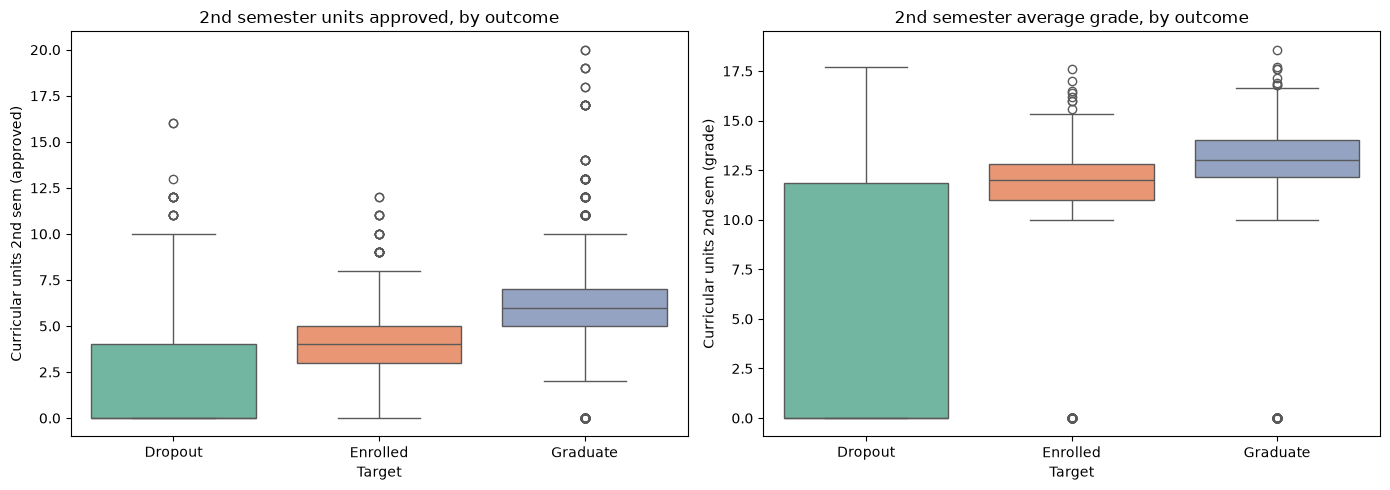

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot 1: how many 2nd-semester course units each outcome group actually passed
sns.boxplot(data=df, x="Target", y="Curricular units 2nd sem (approved)",
            order=["Dropout", "Enrolled", "Graduate"], ax=axes[0], palette="Set2")
axes[0].set_title("2nd semester units approved, by outcome")

# Boxplot 2: average grade achieved in the 2nd semester, by outcome group
sns.boxplot(data=df, x="Target", y="Curricular units 2nd sem (grade)",
            order=["Dropout", "Enrolled", "Graduate"], ax=axes[1], palette="Set2")
axes[1].set_title("2nd semester average grade, by outcome")

plt.tight_layout()
plt.show()


Correlation of numeric features with outcome

C:\Users\USER\AppData\Local\Temp\ipykernel_14328\1923828529.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corrs.values, y=corrs.index, palette="coolwarm_r")
c:\Users\USER\OneDrive\Documents\IT5022_FML_Assignment\IT5022_FML_Assignment_Group\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


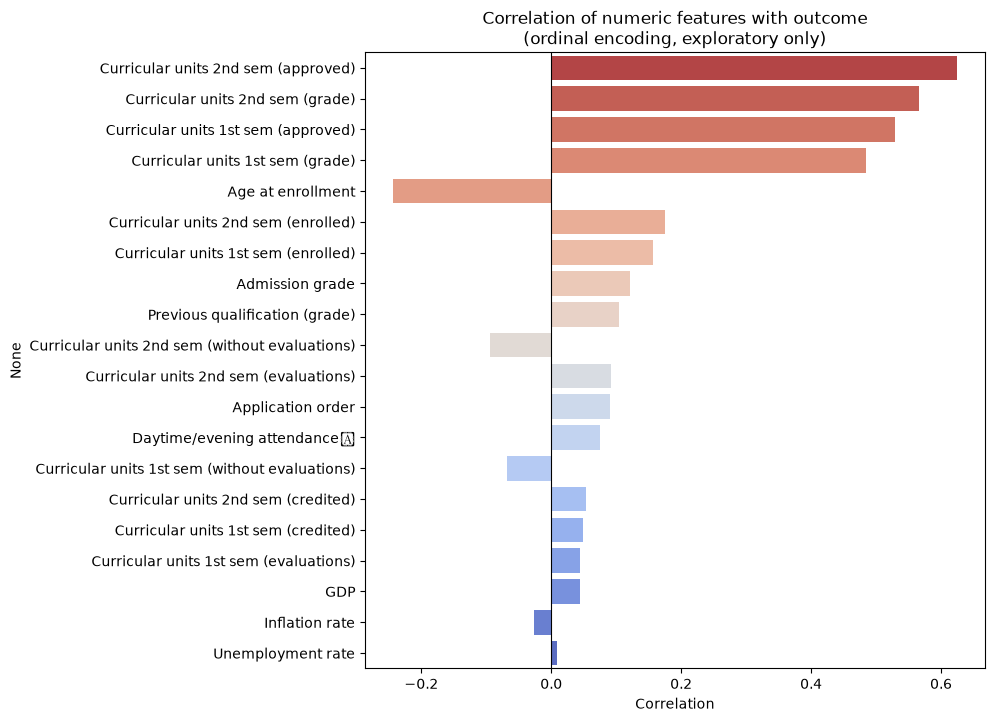

In [9]:
# For this EXPLORATORY correlation ranking only, we encode the target on an ordinal scale
# (Dropout=0 < Enrolled=1 < Graduate=2). This is purely a convenience for ranking features by
# strength of association -- our actual models in Sections 5-7 treat Target as unordered/nominal,
# which is the statistically correct treatment for a 3-class outcome with no natural ordering.
ordinal_target = df["Target"].map({"Dropout": 0, "Enrolled": 1, "Graduate": 2})

# Pearson correlation of each numeric feature with the (ordinal-encoded) target
corrs = df[numeric_cols].corrwith(ordinal_target).sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(x=corrs.values, y=corrs.index, palette="coolwarm_r")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlation of numeric features with outcome\n(ordinal encoding, exploratory only)")
plt.xlabel("Correlation")
plt.show()

Preprocessing

One-hot encode the 9 nominal categorical features (drop_first=True to avoid the dummy variable trap / perfect multicollinearity).

Leave binary (0/1) features as-is -- they're already model-ready.

Standardize continuous/count features (zero mean, unit variance) -- important for Logistic Regression, which is sensitive to feature scale; harmless for Random Forest.

Encode the 3-class text target into integers for scikit-learn.

Stratified train/test split (80/20) — critical here, since a plain random split could by chance further skew the already-imbalanced minority class between train and test.

In [11]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [14]:
# One-hot encode only the nominal columns; everything else passes through unchanged
X = pd.get_dummies(df.drop(columns=["Target"]), columns=nominal_cols, drop_first=True)
y_raw = df["Target"]

# Turn the three text labels into integers 0/1/2 (alphabetical order: Dropout, Enrolled, Graduate)
le = LabelEncoder()
y = le.fit_transform(y_raw)
print("Classes:", list(le.classes_))
print(f"Feature count after one-hot encoding: {X.shape[1]} (started from {df.shape[1]-1} raw columns)")

# stratify=y ensures both train and test sets keep the same ~50/32/18% class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Fit the scaler ONLY on training data, then apply the same transformation to test data --
# this avoids leaking any information about the test set into preprocessing
cols_to_scale = [c for c in numeric_cols if c in X_train.columns]
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("\nTrain class distribution:", np.bincount(y_train))
print("Test class distribution: ", np.bincount(y_test))


Classes: ['Dropout', 'Enrolled', 'Graduate']
Feature count after one-hot encoding: 238 (started from 36 raw columns)

Train class distribution: [1137  635 1767]
Test class distribution:  [284 159 442]
